Dataset loaded successfully!
Dataset shape: (614, 13)

First 5 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Missing values before preprocessing:
Loan_ID               0
Gender               13
Marr

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1



Input Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Output / Target:
Loan_Status

Target values:
['N' 'Y']

Training data size: (491, 11)
Testing data size: (123, 11)

Features standardized successfully.

       DEFAULT KNN MODEL
Default number of neighbors (K): 5
Default KNN Accuracy: 84.55 %

Confusion Matrix - Default KNN:
[[22 16]
 [ 3 82]]

       KNN K-VALUE EXPERIMENT
K = 3 --> Accuracy = 82.93%
K = 5 --> Accuracy = 84.55%
K = 7 --> Accuracy = 84.55%

K Experiment Results:


,K,Accuracy
0,3,0.829268
1,5,0.845528
2,7,0.845528


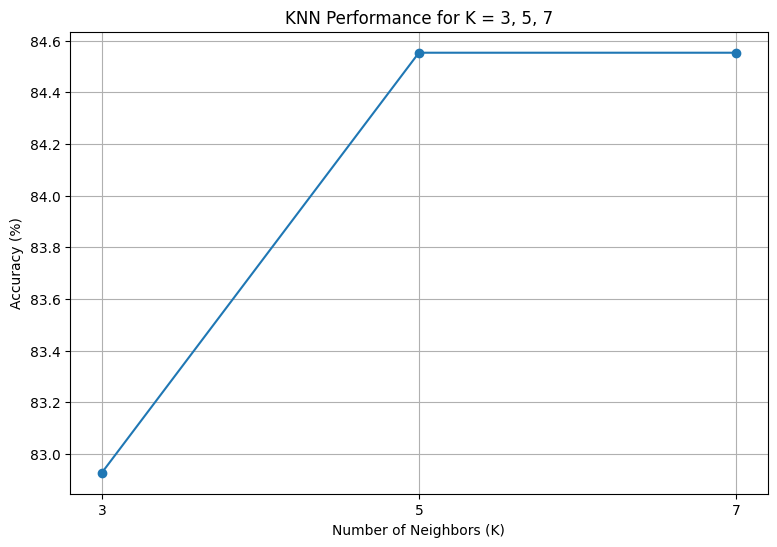


       HYPERPARAMETER TUNING
Best K: 16
Best Cross-Validation Accuracy: 79.63 %

Final Tuned KNN Accuracy: 85.37 %

Confusion Matrix - Tuned KNN:
[[21 17]
 [ 1 84]]


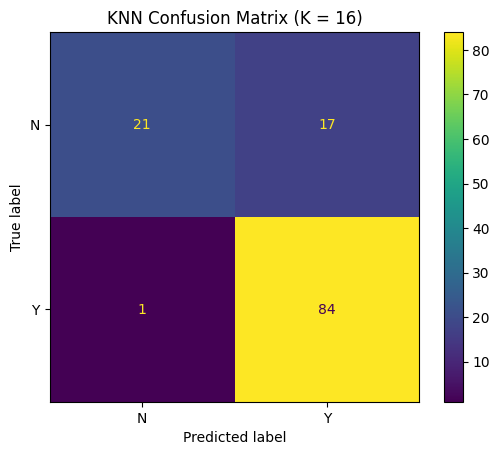


       MODEL COMPARISON


,Model,Accuracy (%)
0,Default KNN (K=5),84.552846
1,Tuned KNN (K=16),85.365854


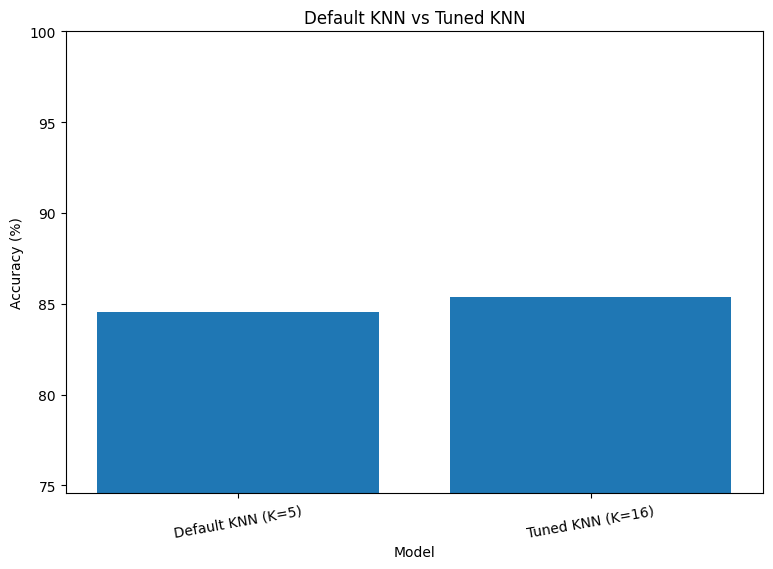


          FINAL PROJECT SUMMARY
Dataset: Loan Prediction Dataset
Number of samples: 614
Number of input features: 11
Training samples: 491
Testing samples: 123

Input Features:
- Gender
- Married
- Dependents
- Education
- Self_Employed
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History
- Property_Area

Output / Target:
- Loan_Status

Default KNN Accuracy: 84.55 %
Best K: 16
Tuned KNN Accuracy: 85.37 %

Project preprocessing and KNN evaluation completed successfully!


In [2]:
# ============================================================
# ASSIGNMENT: K-NEAREST NEIGHBORS (KNN)
# LOAN APPROVAL PREDICTION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ============================================================
# 2. LOAD DATASET
# ============================================================

# Make sure train_u6lujuX_CVtuZ9i.csv is uploaded to Colab
import os
file_path = "train_u6lujuX_CVtuZ9i.csv" if os.path.exists("train_u6lujuX_CVtuZ9i.csv") else "/content/train_u6lujuX_CVtuZ9i.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows of the dataset:")
display(df.head())


# ============================================================
# 3. CHECK DATASET INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing values before preprocessing:")
print(df.isnull().sum())


# ============================================================
# 4. REMOVE LOAN_ID
# ============================================================

# Loan_ID is only an identifier, so it is not useful
# for predicting loan approval.

df = df.drop("Loan_ID", axis=1)


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

# Separate categorical and numerical columns

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

# Fill numerical columns with MEDIAN
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill categorical columns with MODE
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Convert "3+" to "3" in Dependents
df["Dependents"] = df["Dependents"].replace("3+", "3")

print("\nMissing values after preprocessing:")
print(df.isnull().sum())


# ============================================================
# 6. ENCODE CATEGORICAL VARIABLES
# ============================================================

# We use LabelEncoder for categorical variables.

encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

# Encode target variable Loan_Status
target_encoder = LabelEncoder()
df["Loan_Status"] = target_encoder.fit_transform(df["Loan_Status"])

print("\nDataset after encoding:")
display(df.head())


# ============================================================
# 7. SEPARATE INPUT FEATURES AND TARGET
# ============================================================

# INPUT FEATURES
X = df.drop("Loan_Status", axis=1)

# OUTPUT / TARGET
y = df["Loan_Status"]

print("\nInput Features:")
print(X.columns.tolist())

print("\nOutput / Target:")
print("Loan_Status")

print("\nTarget values:")
print(target_encoder.classes_)


# ============================================================
# 8. SPLIT DATASET: 80% TRAINING / 20% TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)


# ============================================================
# 9. STANDARDIZE FEATURES
# ============================================================

# StandardScaler is important for KNN because KNN uses
# distance calculations.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized successfully.")


# ============================================================
# 10. DEFAULT KNN MODEL
# ============================================================

# Assignment requirement:
# Train KNN with DEFAULT PARAMETERS.

default_knn = KNeighborsClassifier()

default_knn.fit(X_train_scaled, y_train)

default_prediction = default_knn.predict(X_test_scaled)

default_accuracy = accuracy_score(
    y_test,
    default_prediction
)

print("\n============================================")
print("       DEFAULT KNN MODEL")
print("============================================")

print("Default number of neighbors (K): 5")
print("Default KNN Accuracy:",
      round(default_accuracy * 100, 2), "%")


# ============================================================
# 11. CONFUSION MATRIX - DEFAULT KNN
# ============================================================

default_cm = confusion_matrix(
    y_test,
    default_prediction
)

print("\nConfusion Matrix - Default KNN:")
print(default_cm)


# ============================================================
# 12. EXPERIMENT WITH K = 3, 5, 7
# ============================================================

k_values = [3, 5, 7]

experiment_results = []

print("\n============================================")
print("       KNN K-VALUE EXPERIMENT")
print("============================================")

for k in k_values:

    knn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    knn_model.fit(
        X_train_scaled,
        y_train
    )

    prediction = knn_model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    experiment_results.append({
        "K": k,
        "Accuracy": accuracy
    })

    print(
        f"K = {k} --> Accuracy = "
        f"{accuracy * 100:.2f}%"
    )


# Convert results to DataFrame
experiment_df = pd.DataFrame(experiment_results)

print("\nK Experiment Results:")
display(experiment_df)


# ============================================================
# 13. VISUALIZE K = 3, 5, 7 PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    experiment_df["K"],
    experiment_df["Accuracy"] * 100,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy (%)")
plt.title("KNN Performance for K = 3, 5, 7")
plt.xticks([3, 5, 7])
plt.grid(True)

plt.show()


# ============================================================
# 14. HYPERPARAMETER TUNING
# ============================================================

# Tune the n_neighbors hyperparameter.

parameter_grid = {
    "n_neighbors": range(1, 21)
}

knn_for_tuning = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn_for_tuning,
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(
    X_train_scaled,
    y_train
)

best_k = grid_search.best_params_["n_neighbors"]

print("\n============================================")
print("       HYPERPARAMETER TUNING")
print("============================================")

print("Best K:", best_k)
print(
    "Best Cross-Validation Accuracy:",
    round(grid_search.best_score_ * 100, 2),
    "%"
)


# ============================================================
# 15. TRAIN FINAL TUNED KNN MODEL
# ============================================================

best_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn.fit(
    X_train_scaled,
    y_train
)

tuned_prediction = best_knn.predict(
    X_test_scaled
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_prediction
)

print("\nFinal Tuned KNN Accuracy:",
      round(tuned_accuracy * 100, 2), "%")


# ============================================================
# 16. FINAL CONFUSION MATRIX
# ============================================================

tuned_cm = confusion_matrix(
    y_test,
    tuned_prediction
)

print("\nConfusion Matrix - Tuned KNN:")
print(tuned_cm)


# ============================================================
# 17. DISPLAY CONFUSION MATRIX GRAPH
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=target_encoder.classes_
)

disp.plot()

plt.title(
    f"KNN Confusion Matrix (K = {best_k})"
)

plt.show()


# ============================================================
# 18. COMPARE DEFAULT AND TUNED KNN
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Default KNN (K=5)",
        f"Tuned KNN (K={best_k})"
    ],
    "Accuracy": [
        default_accuracy,
        tuned_accuracy
    ]
})

comparison["Accuracy (%)"] = (
    comparison["Accuracy"] * 100
)

print("\n============================================")
print("       MODEL COMPARISON")
print("============================================")

display(
    comparison[
        ["Model", "Accuracy (%)"]
    ]
)


# ============================================================
# 19. ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Default KNN vs Tuned KNN")

plt.ylim(
    max(0, comparison["Accuracy (%)"].min() - 10),
    100
)

plt.xticks(rotation=10)

plt.show()


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n============================================")
print("          FINAL PROJECT SUMMARY")
print("============================================")

print("Dataset:", "Loan Prediction Dataset")

print("Number of samples:", len(df))

print("Number of input features:", X.shape[1])

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

print("\nInput Features:")
for feature in X.columns:
    print("-", feature)

print("\nOutput / Target:")
print("- Loan_Status")

print("\nDefault KNN Accuracy:",
      round(default_accuracy * 100, 2), "%")

print("Best K:", best_k)

print("Tuned KNN Accuracy:",
      round(tuned_accuracy * 100, 2), "%")

print("\nProject preprocessing and KNN evaluation completed successfully!")

In [4]:
import joblib

# Save the final tuned KNN model
joblib.dump(best_knn, "knn_model.pkl")

# Save the StandardScaler
joblib.dump(scaler, "scaler.pkl")

# Save categorical encoders
joblib.dump(encoders, "encoders.pkl")

# Save Loan_Status encoder
joblib.dump(target_encoder, "target_encoder.pkl")

print("All trained model files saved successfully!")

print("\nFiles created:")
print("1. knn_model.pkl")
print("2. scaler.pkl")
print("3. encoders.pkl")
print("4. target_encoder.pkl")
# Also copy to backend/models/ if it exists
import os, shutil
target_dir = os.path.join("backend", "models")
if os.path.exists(target_dir):
    for f_name in ["knn_model.pkl", "scaler.pkl", "encoders.pkl", "target_encoder.pkl"]:
        if os.path.exists(f_name):
            shutil.copy(f_name, os.path.join(target_dir, f_name))
    print("Model artifacts synchronized to backend/models/ directory!")


All trained model files saved successfully!

Files created:
1. knn_model.pkl
2. scaler.pkl
3. encoders.pkl
4. target_encoder.pkl
